# Data Analysis: Global air temperature observations

### Loading Observations

In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [11]:
obs = pd.read_csv('./observations.csv', compression="gzip", parse_dates=["time"])

In [21]:
print(obs.shape)
print(obs.columns)

(9235846, 7)
Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude'],
      dtype='object')


In [268]:
obs.head(30)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,day_of_year,sin_day,cos_day,hour,sin_hour,cos_hour,temp_celcius
0,274.1,2025-02-01 00:00:00+00:00,1001,temperature_at_screen_level,70.933,-8.667,10.0,32,0.523416,0.852078,0,0.000000,1.000000,1.1
1,269.1,2025-02-01 00:00:00+00:00,1003,temperature_at_screen_level,77.000,15.500,10.0,32,0.523416,0.852078,0,0.000000,1.000000,-3.9
2,272.6,2025-02-01 00:00:00+00:00,1007,temperature_at_screen_level,78.923,11.933,8.0,32,0.523416,0.852078,0,0.000000,1.000000,-0.4
3,269.2,2025-02-01 00:00:00+00:00,1008,temperature_at_screen_level,78.250,15.467,28.0,32,0.523416,0.852078,0,0.000000,1.000000,-3.8
4,276.2,2025-02-01 00:00:00+00:00,1010,temperature_at_screen_level,69.307,16.131,10.0,32,0.523416,0.852078,0,0.000000,1.000000,3.2
5,275.8,2025-02-01 00:00:00+00:00,1015,temperature_at_screen_level,69.600,17.831,33.0,32,0.523416,0.852078,0,0.000000,1.000000,2.8
6,275.5,2025-02-01 01:00:00+00:00,1015,temperature_at_screen_level,69.600,17.831,33.0,32,0.523416,0.852078,1,0.258819,0.965926,2.5
7,276.8,2025-02-01 02:00:00+00:00,1015,temperature_at_screen_level,69.600,17.831,33.0,32,0.523416,0.852078,2,0.500000,0.866025,3.8
8,276.4,2025-02-01 03:00:00+00:00,1015,temperature_at_screen_level,69.600,17.831,33.0,32,0.523416,0.852078,3,0.707107,0.707107,3.4
9,276.7,2025-02-01 04:00:00+00:00,1015,temperature_at_screen_level,69.600,17.831,33.0,32,0.523416,0.852078,4,0.866025,0.500000,3.7


### EDA

In [299]:
# Counting unique locations
unique_locations = obs[['latitude', 'longitude']].drop_duplicates()
print("Number of unique locations:", len(unique_locations))
unique_locations

Number of unique locations: 7869


,latitude,longitude
0,70.933,-8.667
1,77.000,15.500
2,78.923,11.933
3,78.250,15.467
4,69.307,16.131
...,...,...
8851126,-9.347,-77.599
8851128,-9.879,-76.207
8909619,-11.740,24.431
9087503,21.349,39.974


In [266]:
# Essentially 'wmo_id' are weather station Ids
location_data = obs['wmo_id'].value_counts().reset_index()
location_data.columns = ['wmo_id', 'obs_count']
location_data

,wmo_id,obs_count
0,7579,2652
1,99095,2652
2,15420,2652
3,15410,2652
4,7622,2652
...,...,...
7854,38637,1
7855,38665,1
7856,38755,1
7857,38759,1


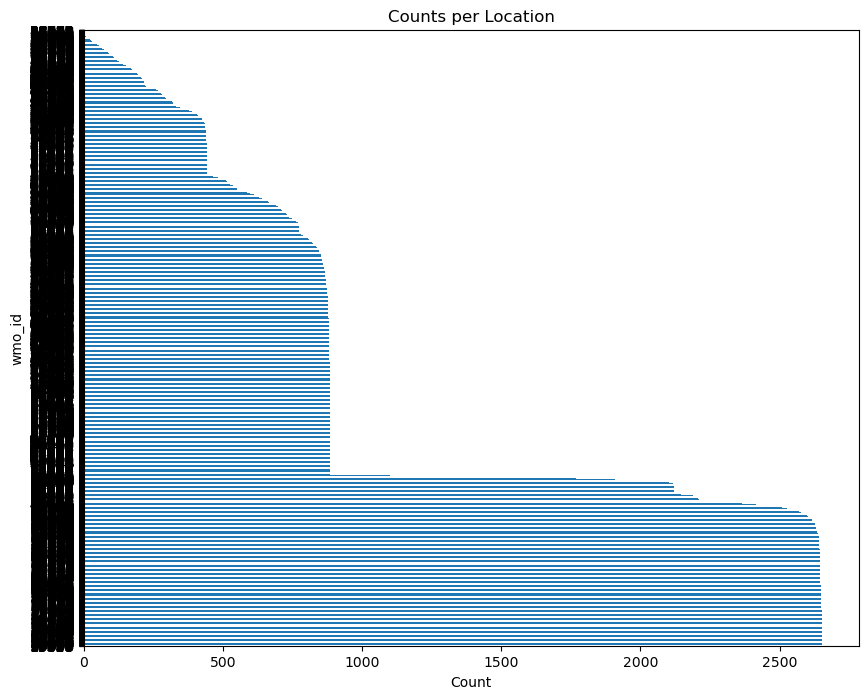

In [281]:
#Plotting observation counts for each location (wmo_id)
obs['wmo_id'].value_counts().plot(kind='barh', figsize=(10,8))
plt.xlabel('Count')
plt.ylabel('wmo_id')
plt.title('Counts per Location')
plt.show()

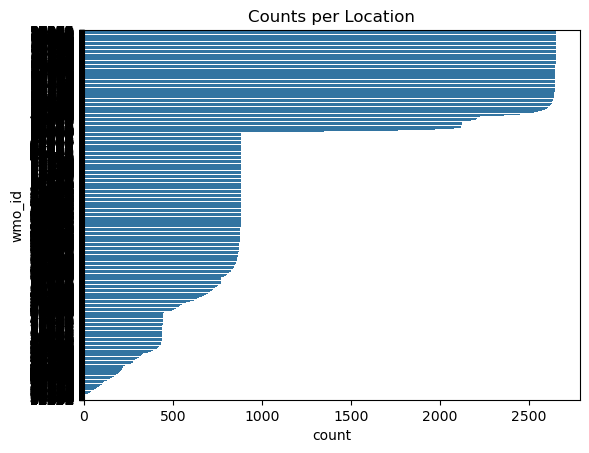

In [272]:
#Another plot
sns.countplot(data=obs, y='wmo_id', order=obs['wmo_id'].value_counts().index)
plt.title('Counts per Location')
plt.show()


In [138]:
# Converting date to a cyclic pattern in a 365 day cycle
obs['day_of_year'] = obs['time'].dt.dayofyear
obs['sin_day'] = np.sin(2 * np.pi * obs['day_of_year'] / 365)
obs['cos_day'] = np.cos(2 * np.pi * obs['day_of_year'] / 365)

# Converting time to a cyclic pattern - 24 hour cycle
obs['hour'] = pd.to_datetime(obs['time']).dt.hour
obs['sin_hour'] = np.sin(2 * np.pi * obs['hour'] / 24)
obs['cos_hour'] = np.cos(2 * np.pi * obs['hour'] / 24)

obs['temp_celcius'] = obs['ob_value'] - 273.0

In [140]:
obs.tail(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,day_of_year,sin_day,cos_day,hour,sin_hour,cos_hour,temp_celcius
9235836,285.8,2025-05-20 08:00:00+00:00,99466,temperature_at_screen_level,57.618,-7.448,133.0,140,0.668064,-0.744104,8,0.866025,-5.000000e-01,12.8
9235837,286.3,2025-05-20 09:00:00+00:00,99466,temperature_at_screen_level,57.618,-7.448,133.0,140,0.668064,-0.744104,9,0.707107,-7.071068e-01,13.3
9235838,287.3,2025-05-20 10:00:00+00:00,99466,temperature_at_screen_level,57.618,-7.448,133.0,140,0.668064,-0.744104,10,0.500000,-8.660254e-01,14.3
9235839,287.6,2025-05-20 11:00:00+00:00,99466,temperature_at_screen_level,57.618,-7.448,133.0,140,0.668064,-0.744104,11,0.258819,-9.659258e-01,14.6
9235840,286.2,2025-05-20 06:00:00+00:00,99500,temperature_at_screen_level,34.933,32.867,1952.0,140,0.668064,-0.744104,6,1.000000,6.123234e-17,13.2
9235841,286.7,2025-05-20 07:00:00+00:00,99500,temperature_at_screen_level,34.933,32.867,1952.0,140,0.668064,-0.744104,7,0.965926,-2.588190e-01,13.7
9235842,287.0,2025-05-20 08:00:00+00:00,99500,temperature_at_screen_level,34.933,32.867,1952.0,140,0.668064,-0.744104,8,0.866025,-5.000000e-01,14.0
9235843,287.6,2025-05-20 09:00:00+00:00,99500,temperature_at_screen_level,34.933,32.867,1952.0,140,0.668064,-0.744104,9,0.707107,-7.071068e-01,14.6
9235844,287.8,2025-05-20 10:00:00+00:00,99500,temperature_at_screen_level,34.933,32.867,1952.0,140,0.668064,-0.744104,10,0.500000,-8.660254e-01,14.8
9235845,285.6,2025-05-20 11:00:00+00:00,99500,temperature_at_screen_level,34.933,32.867,1952.0,140,0.668064,-0.744104,11,0.258819,-9.659258e-01,12.6


In [277]:
# why is this weird?
print(obs['temp_celcius'].min())
print(obs['temp_celcius'].max())

-99.80000000000001
99.69999999999999


In [119]:
# A single value in all rows -> doesn't seem important
obs['diagnostic'].value_counts()

diagnostic
temperature_at_screen_level    9235846
Name: count, dtype: int64

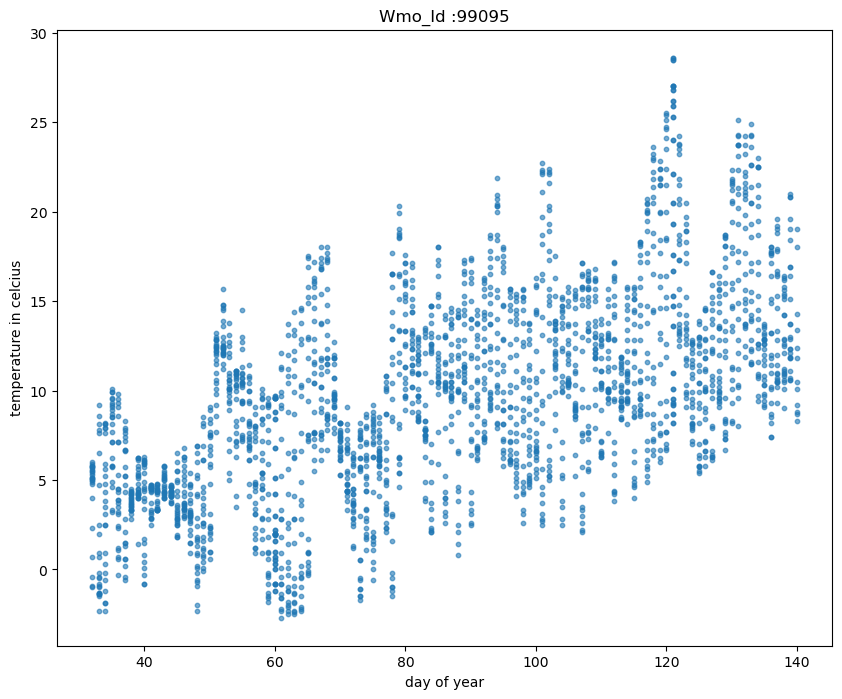

In [279]:
#Plotting the temperature variation for a site
wmo = 99095
plot_data = obs[obs['wmo_id'] == wmo][['day_of_year', 'temp_celcius']]

plt.figure(figsize=(10,8))
plt.scatter(plot_data['day_of_year'], plot_data['temp_celcius'], alpha = 0.6, s=10)
plt.title('Wmo_Id :'+ str(wmo))
plt.xlabel('day of year')
plt.ylabel('temperature in celcius')
plt.show()

#maybe fit a NW smoothing curve? 

In [ ]:
#Plotting a map - Still learning
import folium

center = [obs['latitude'].mean(), obs['longitude'].mean()]
m = folium.Map(location=center, zoom_start=6)

# Add points to the map
for _, row in obs.iterrows():
    folium.CircleMarker(
        location=[obs['latitude'], obs['longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_opacity=0.5
    ).add_to(m)

m.save("locations_map.html")


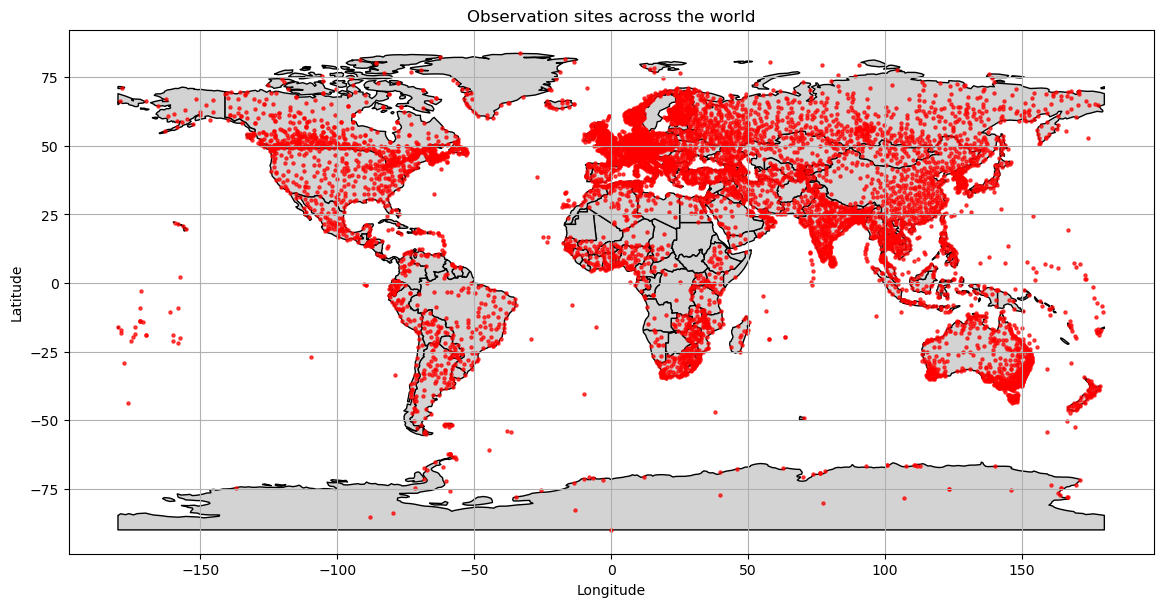

<Figure size 640x480 with 0 Axes>

In [309]:
gdf = gpd.GeoDataFrame(unique_locations, geometry = gpd.points_from_xy(unique_locations['longitude'], unique_locations['latitude']), crs="EPSG:4326")

world = gpd.read_file('./ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
#Loading world map
fig, ax = plt.subplots(figsize=(14,10))
world.plot(ax=ax, color='lightgray', edgecolor='black')
gdf.plot(ax=ax, color='red', markersize=5, alpha=0.7)

plt.title("Observation sites across the world")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()
plt.savefig('./stations_on_world_map.png')